In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Cargar tus nuevos datos ---
# Reemplaza el path si es necesario
parquet_path = "/home/lsilva/Github/ADST_Ruso/parquet/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.parquet"
df_new = pd.read_parquet(parquet_path)

# (Opcional) Si querés corregir el error de logE_REC = -inf que vimos
df_new.replace([np.inf, -np.inf], np.nan, inplace=True)
df_new.dropna(subset=['logE_REC'], inplace=True)

print(f"DataFrame 'df_new' cargado con {len(df_new)} filas (counters).")
print(df_new.head())

DataFrame 'df_new' cargado con 12251 filas (counters).
                                            event_id    logE_MC   theta_MC  \
0  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
1  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
2  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
3  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
4  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   

       phi_MC primary   logE_REC  theta_REC     phi_REC  counterId  \
0  266.129022      He  17.424415   9.516247  269.459517     104022   
1  266.129022      He  17.424415   9.516247  269.459517     104023   
2  266.129022      He  17.424415   9.516247  269.459517     104041   
3  266.129022      He  17.424415   9.516247  269.459517     104021   
4  266.129022      He  17.424415   9.516247  269.459517     104009   

      nMuones  ...     y_plane  phi_plane      r_core  

Generando gráfico 3D...


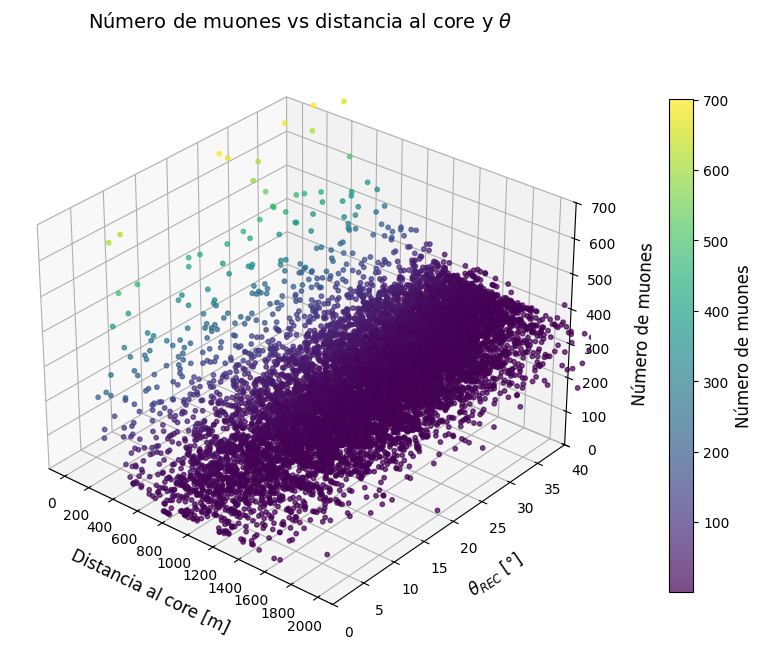

In [18]:
print("Generando gráfico 3D...")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# (Opcional) Filtremos un poco para que el plot sea más claro
# ej: sacamos counters sin muones o muy lejanos
df_plot = df_new[
    (df_new['nMuones'] > 0) &
    (df_new['r_core'] < 2000) # (Ajustá este límite si es necesario)
]

# Scatter
sc = ax.scatter(
    df_plot["r_core"],
    df_plot["theta_REC"],  # <-- Columna renombrada
    df_plot["nMuones"],
    c=df_plot["nMuones"], 
    cmap="viridis", 
    alpha=0.7,
    s=10 # Hago los puntos un poco más chicos
)

# Labels
ax.set_xlabel("Distancia al core [m]", fontsize=12, labelpad=10)
ax.set_ylabel(r"$\theta_{REC}$ [°]", fontsize=12, labelpad=10) # <-- Label actualizado
ax.set_zlabel("Número de muones", fontsize=12, labelpad=10)
plt.title(r"Número de muones vs distancia al core y $\theta$", fontsize=14, pad=20)

# Mejorar ticks (usando tu configuración)
ax.set_xticks(np.arange(0, 2000 + 1, 200))
ax.set_yticks(np.arange(0, 40 + 1, 5))
ax.set_ylim(0, 40) # (Tal vez quieras subir este límite si tus datos llegan a 60°)

# Zticks: Usar un log-scale o binear puede ser mejor
# pero siguiendo tu código original:
z_max = df_plot["nMuones"].max()
ax.set_zticks(np.arange(0, z_max + 1, 100)) # Ajustado a 100, ya que 50 era muy denso
ax.set_zlim(0, z_max) # Asegurarse de que el eje Z llegue al máximo

# Añadir barra de color
cbar = plt.colorbar(sc, pad=0.1, shrink=0.8)
cbar.set_label("Número de muones", fontsize=12)

# Rotar la vista
ax.view_init(elev=30, azim=310)

# Grid
ax.grid(True)

plt.show()

In [19]:
# --- 3. Crear DataFrame de EVENTOS ---
# Columnas que son únicas para cada evento (lluvia)
event_cols = [
    "run_number",
    "event_id",
    "logE_MC", "theta_MC", "phi_MC", 
    "primary", # 'primary' es de MC, así que también es por evento
    "logE_REC", "theta_REC", "phi_REC"
]

# Usamos drop_duplicates() para colapsar las 10-12 filas de cada evento en UNA sola.
df_events = df_new[event_cols].drop_duplicates()

print(f"DataFrame 'df_events' (lluvias) creado con {len(df_events)} filas únicas.")
df_events.head()

DataFrame 'df_events' (lluvias) creado con 1167 filas únicas.


,run_number,event_id,logE_MC,theta_MC,phi_MC,primary,logE_REC,theta_REC,phi_REC
0,10,Library_Prague_Santos_Yushkov:Run_10000:Shower...,17.557002,10.497525,266.129022,He,17.424415,9.516247,269.459517
7,10,Library_Prague_Santos_Yushkov:Run_10001:Shower...,17.514259,3.048157,315.899666,He,17.423894,3.140957,323.483553
15,10,Library_Prague_Santos_Yushkov:Run_10002:Shower...,17.509618,28.251578,331.123960,He,17.406819,27.135014,331.405738
24,10,Library_Prague_Santos_Yushkov:Run_10003:Shower...,17.896363,36.831416,117.406958,He,17.780786,36.541166,118.938084
37,10,Library_Prague_Santos_Yushkov:Run_10004:Shower...,17.755350,53.969303,169.547926,He,17.587915,53.550577,168.552741


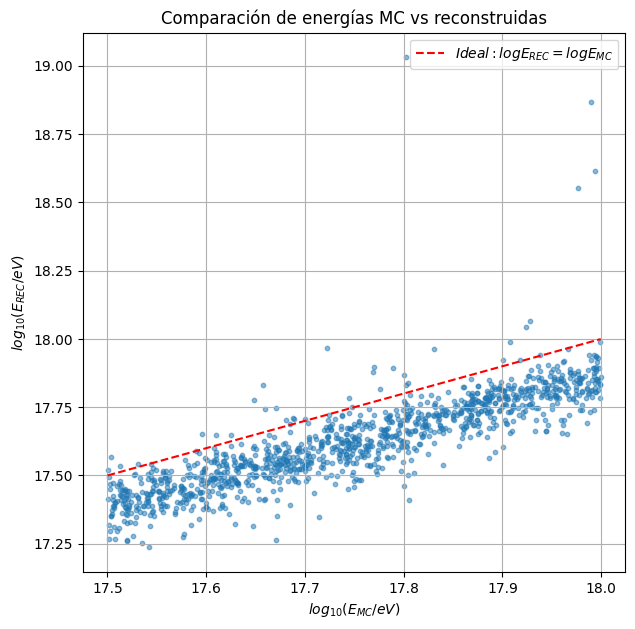

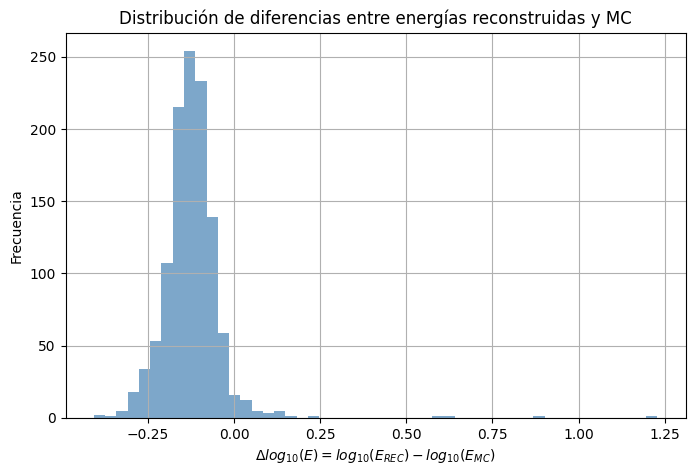

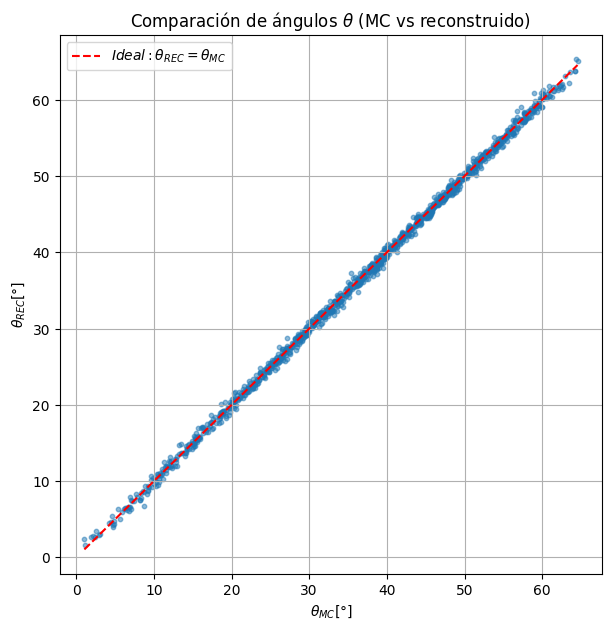

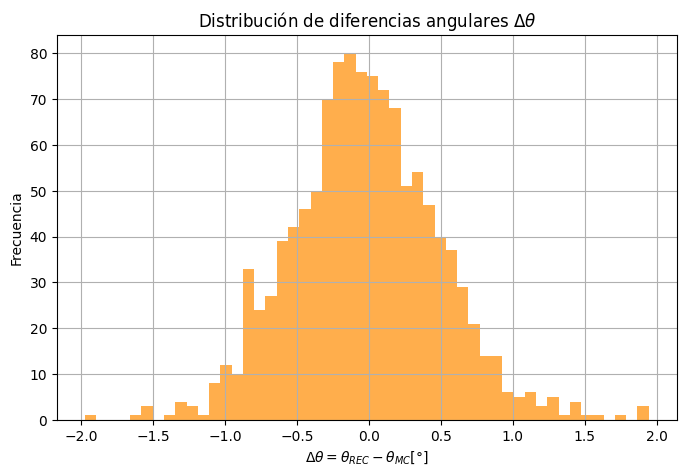

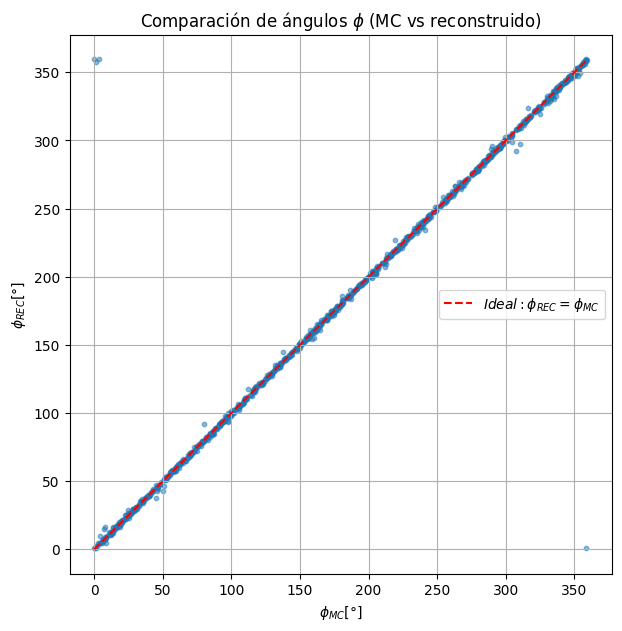

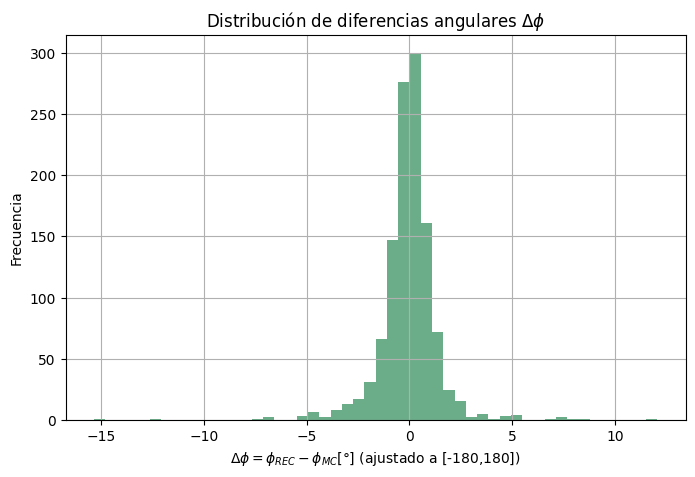

=== Energía (log10) ===
Promedio ΔlogE: -0.1248
Desviación estándar ΔlogE: 0.0896

=== Ángulo cenital θ ===
Promedio Δθ: -0.0251°
Desviación estándar Δθ: 0.5107°

=== Ángulo azimutal φ ===
Mediana Δφ: 0.0161°
MAD Δφ: 0.5663°


In [20]:
# --- 1. PLOTS DE RESOLUCIÓN (usando df_events) ---

# -------------------------------
# Comparar logE_MC vs logE_REC
# -------------------------------
plt.figure(figsize=(7, 7))
# ❗️ CAMBIO: df_all -> df_events
plt.scatter(df_events["logE_MC"], df_events["logE_REC"], s=10, alpha=0.5)
plt.plot([df_events["logE_MC"].min(), df_events["logE_MC"].max()],
         [df_events["logE_MC"].min(), df_events["logE_MC"].max()],
         'r--', label=r"$Ideal: logE_{REC} = logE_{MC}$")

plt.xlabel(r"$log_{10}(E_{MC} / eV)$")
plt.ylabel(r"$log_{10}(E_{REC} / eV)$")
plt.title("Comparación de energías MC vs reconstruidas")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Diferencia ΔlogE = logE_REC - logE_MC
# -------------------------------
# ❗️ CAMBIO: df_all -> df_events
deltaE = df_events["logE_REC"] - df_events["logE_MC"]
# (El resto de tu código de histograma es idéntico)
plt.figure(figsize=(8, 5))
plt.hist(deltaE.dropna(), bins=50, alpha=0.7, color='steelblue') # .dropna() por seguridad
plt.xlabel(r"$\Delta log_{10}(E) = log_{10}(E_{REC}) - log_{10}(E_{MC})$")
plt.ylabel("Frecuencia")
plt.title("Distribución de diferencias entre energías reconstruidas y MC")
plt.grid(True)
plt.show()

# -------------------------------
# THETA
# -------------------------------
# ❗️ CAMBIO: df_all -> df_events
plt.figure(figsize=(7,7))
plt.scatter(df_events["theta_MC"], df_events["theta_REC"], s=10, alpha=0.5)
plt.plot([df_events["theta_MC"].min(), df_events["theta_MC"].max()],
         [df_events["theta_MC"].min(), df_events["theta_MC"].max()],
         'r--', label=r"$Ideal: \theta_{REC} = \theta_{MC}$")
plt.xlabel(r"$\theta_{MC} [°]$")
plt.ylabel(r"$\theta_{REC} [°]$")
plt.title(r"Comparación de ángulos $\theta$ (MC vs reconstruido)")
plt.legend()
plt.grid(True)
plt.show()

# ❗️ CAMBIO: df_all -> df_events
delta_theta = df_events["theta_REC"] - df_events["theta_MC"]

plt.figure(figsize=(8,5))
plt.hist(delta_theta.dropna(), bins=50, alpha=0.7, color='darkorange') # .dropna()
plt.xlabel(r"$\Delta \theta = \theta_{REC} - \theta_{MC} [°]$")
plt.ylabel("Frecuencia")
plt.title(r"Distribución de diferencias angulares $\Delta \theta$")
plt.grid(True)
plt.show()

# -------------------------------
# PHI
# -------------------------------
# ❗️ CAMBIO: df_all -> df_events
plt.figure(figsize=(7,7))
plt.scatter(df_events["phi_MC"], df_events["phi_REC"], s=10, alpha=0.5)
plt.plot([df_events["phi_MC"].min(), df_events["phi_MC"].max()],
         [df_events["phi_MC"].min(), df_events["phi_MC"].max()],
         'r--', label=r"$Ideal: \phi_{REC} = \phi_{MC}$")
plt.xlabel(r"$\phi_{MC} [°]$")
plt.ylabel(r"$\phi_{REC} [°]$")
plt.title(r"Comparación de ángulos $\phi$ (MC vs reconstruido)")
plt.legend()
plt.grid(True)
plt.show()

# Cuidar el wrap-around de phi (0–360)
# ❗️ CAMBIO: df_all -> df_events
delta_phi = (df_events["phi_REC"] - df_events["phi_MC"] + 180) % 360 - 180

plt.figure(figsize=(8,5))
plt.hist(delta_phi.dropna(), bins=50, alpha=0.7, color='seagreen') # .dropna()
plt.xlabel(r"$\Delta \phi = \phi_{REC} - \phi_{MC} [°]$ (ajustado a [-180,180])")
plt.ylabel("Frecuencia")
plt.title(r"Distribución de diferencias angulares $\Delta \phi$")
plt.grid(True)
plt.show()

# -------------------------------
# Resumen de Métricas
# -------------------------------
# Mediana y MAD de Δφ
median_phi = np.median(delta_phi.dropna())
mad_phi = np.median(np.abs(delta_phi.dropna() - median_phi))

print("=== Energía (log10) ===")
print(f"Promedio ΔlogE: {deltaE.mean():.4f}")
print(f"Desviación estándar ΔlogE: {deltaE.std():.4f}\n")

print("=== Ángulo cenital θ ===")
print(f"Promedio Δθ: {delta_theta.mean():.4f}°")
print(f"Desviación estándar Δθ: {delta_theta.std():.4f}°\n")

print("=== Ángulo azimutal φ ===")
print(f"Mediana Δφ: {median_phi:.4f}°")
print(f"MAD Δφ: {mad_phi:.4f}°")

Estadísticos por counter:
   counterId   promedio    std_dev  cantidad
0     104001  10.533145  30.032656       282
1     104002   9.132689  19.769949       263
2     104003  10.606158  37.026091       296
3     104004  11.879356  34.014357       279
4     104005  14.519852  42.939214       282


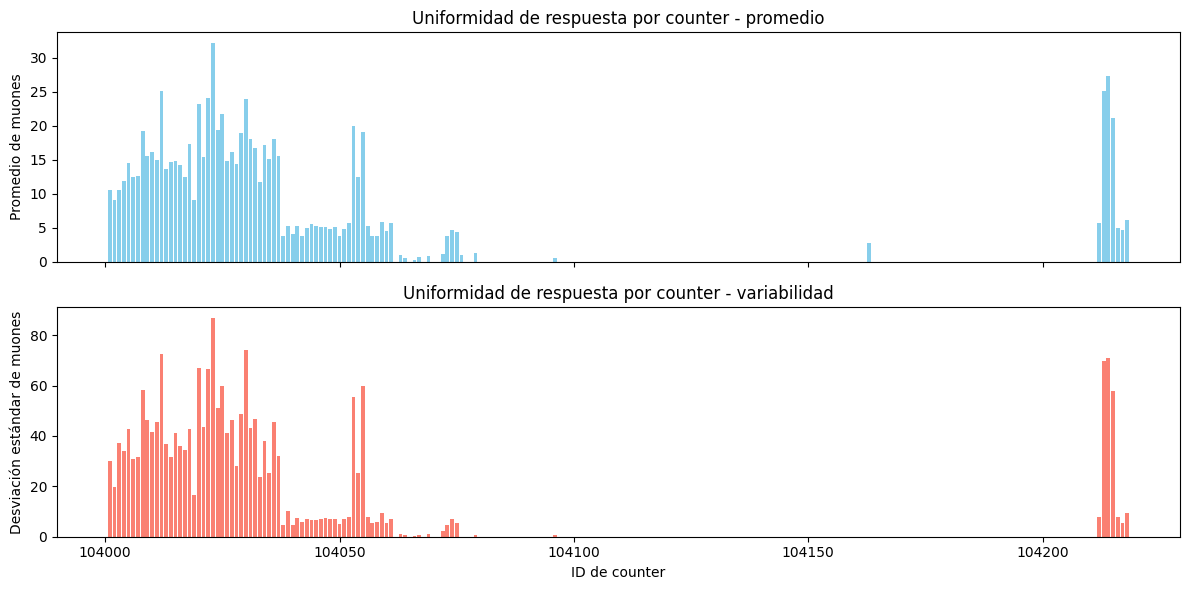

In [21]:
# -------------------------------
# MÉTODO NUEVO (PANDAS, 1 LÍNEA)
# -------------------------------
# Agrupa por 'counterId', toma la columna 'nMuones' y calcula 
# el promedio, la desviación estándar y el conteo para cada counter.
counter_stats = df_new.groupby('counterId')['nMuones'].agg(
    promedio='mean', 
    std_dev='std',
    cantidad='count'
).reset_index()

print("Estadísticos por counter:")
print(counter_stats.head())

# -------------------------------
# Visualización (adaptada al nuevo DataFrame)
# -------------------------------
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Promedio
axs[0].bar(counter_stats['counterId'], counter_stats['promedio'], color='skyblue')
axs[0].set_ylabel("Promedio de muones")
axs[0].set_title("Uniformidad de respuesta por counter - promedio")

# Desviación estándar
axs[1].bar(counter_stats['counterId'], counter_stats['std_dev'], color='salmon')
axs[1].set_ylabel("Desviación estándar de muones")
axs[1].set_xlabel("ID de counter")
axs[1].set_title("Uniformidad de respuesta por counter - variabilidad")

plt.tight_layout()
plt.show()

Rango de Theta en los datos: [1.63°, 65.29°]
Bordes de bins en Theta (grados): [ 0.         21.71553123 31.55098231 39.85570743 47.73117785 55.8266607
 65.        ]
Ploteando bin 0: Mapa polar, $\theta \approx$ [0.0°, 21.7°]


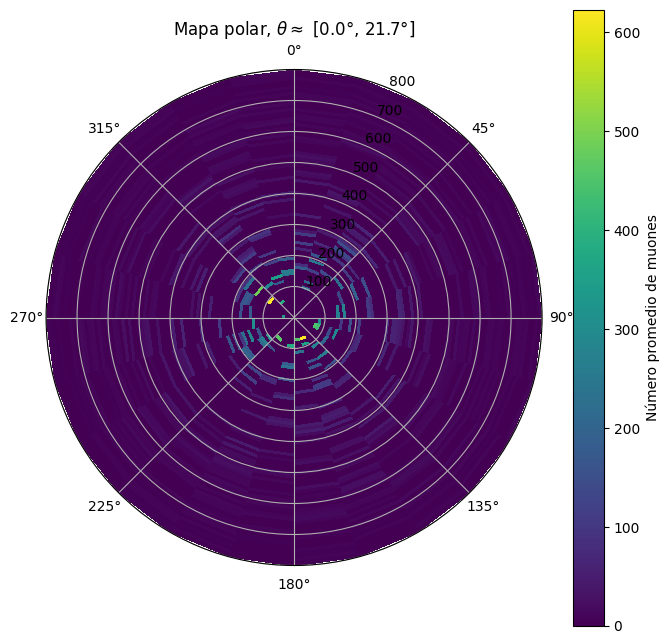

Ploteando bin 1: Mapa polar, $\theta \approx$ [21.7°, 31.6°]


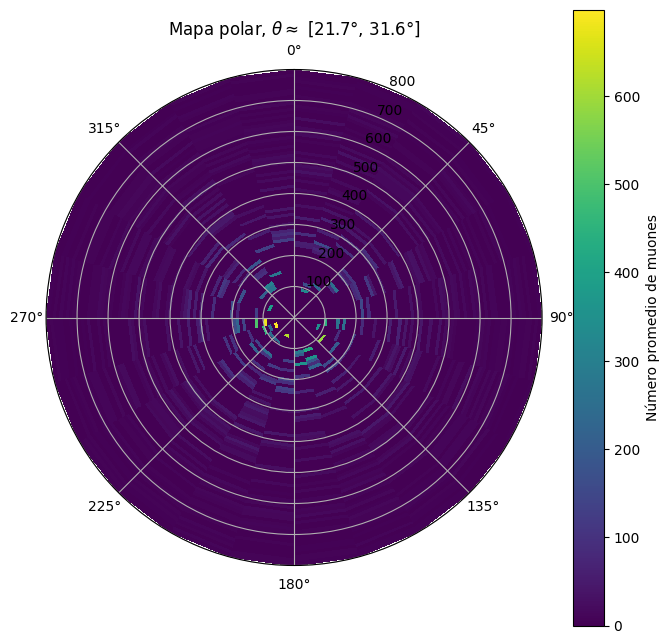

Ploteando bin 2: Mapa polar, $\theta \approx$ [31.6°, 39.9°]


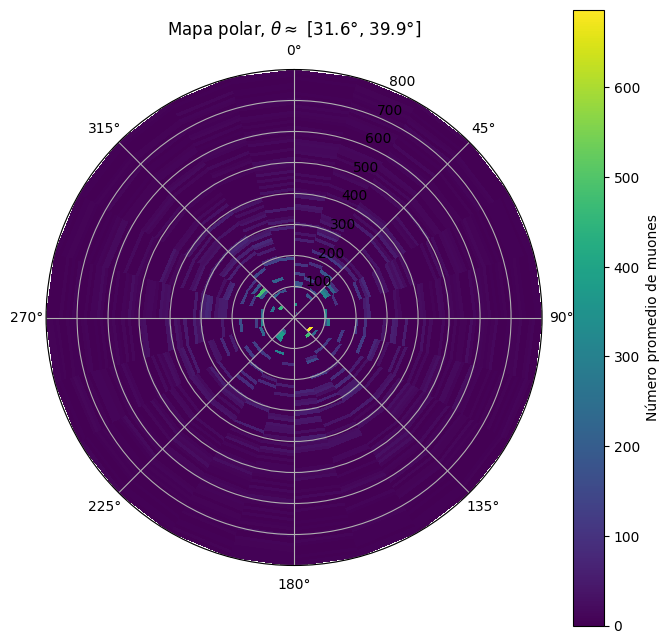

Ploteando bin 3: Mapa polar, $\theta \approx$ [39.9°, 47.7°]


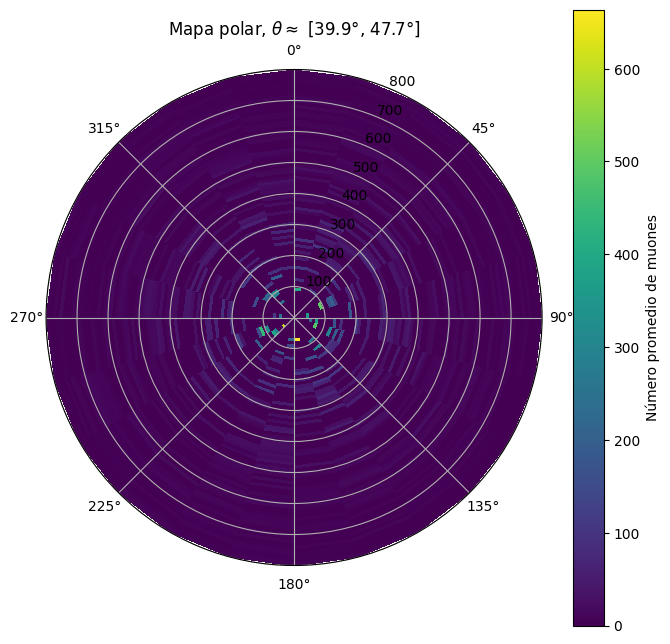

Ploteando bin 4: Mapa polar, $\theta \approx$ [47.7°, 55.8°]


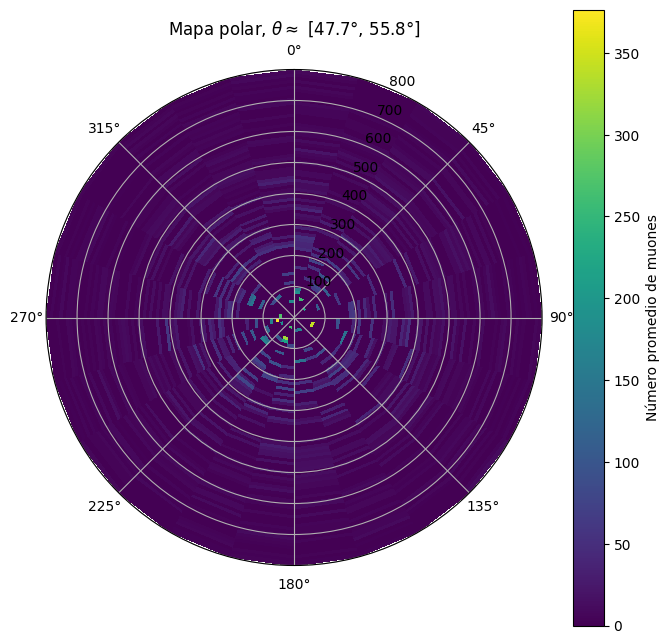

Ploteando bin 5: Mapa polar, $\theta \approx$ [55.8°, 65.0°]


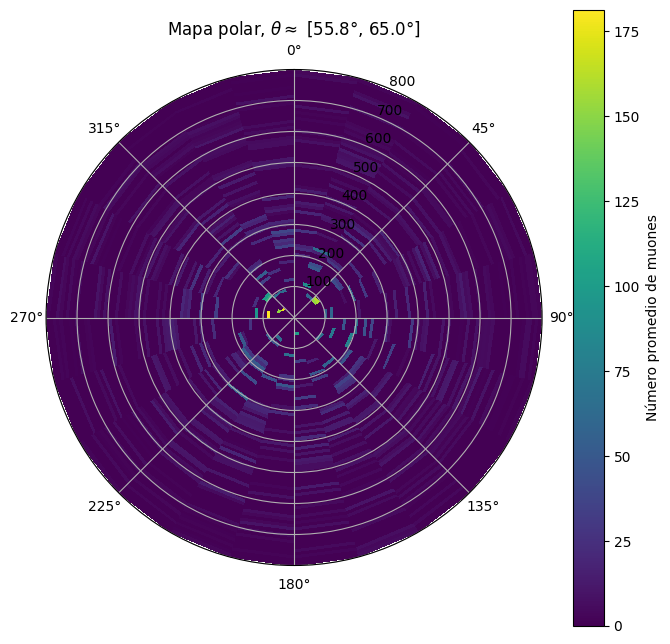

In [28]:
# --- 3. MAPA POLAR (usando df_new) ---

# -------------------------------
# Parámetros de binning (r y phi)
# -------------------------------
r_max = 800
r_bin_size = 10
phi_bins = 24 # 100 es demasiado para ver asimetrías, 12 o 24 es mejor

r_bins = np.arange(0, r_max + r_bin_size, r_bin_size)
phi_edges = np.linspace(0, 2*np.pi, phi_bins + 1)
R, Phi = np.meshgrid(r_bins, phi_edges) # Meshgrid para el plot

# -------------------------------
# Binning en sin^2(theta)
# -------------------------------
N_theta_bins = 6
theta_min_deg = 0
theta_max_deg = 65

# Verificamos el rango real
theta_min_real = df_new['theta_REC'].min()
theta_max_real = df_new['theta_REC'].max()
print(f"Rango de Theta en los datos: [{theta_min_real:.2f}°, {theta_max_real:.2f}°]")
# Usamos el máximo real si es menor a 65
theta_max_deg = min(theta_max_deg, theta_max_real) 

# 1. Crear los bins en el espacio de sin^2(theta)
s2_min = np.sin(np.deg2rad(theta_min_deg))**2
s2_max = np.sin(np.deg2rad(theta_max_deg))**2
s2_bins = np.linspace(s2_min, s2_max, N_theta_bins + 1)

# 2. Convertir los bordes de los bins de vuelta a grados (para las etiquetas)
theta_bins_deg = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))

print(f"Bordes de bins en Theta (grados): {theta_bins_deg}")

# 3. Asignar cada FILA (counter) a un bin de theta
# Convertimos theta_REC a sin^2(theta) para binear
df_new['s2_theta'] = np.sin(np.deg2rad(df_new['theta_REC']))**2
# pd.cut asigna cada fila a un bin
# (labels=False nos da un índice: 0, 1, 2, 3, 4, 5)
df_new['theta_bin'] = pd.cut(df_new['s2_theta'], bins=s2_bins, labels=False, include_lowest=True)

# -------------------------------
# Iterar sobre cada bin de theta
# -------------------------------
# Filtramos datos malos de una vez
df_mapa_total = df_new[
    (df_new['r_core'].between(0, r_max)) &
    (df_new['nMuones'].notna()) &
    (df_new['phi_plane'].notna())
].copy()


for i in range(N_theta_bins):
    
    # Seleccionar solo las filas de este bin de theta
    df_bin = df_mapa_total[df_mapa_total['theta_bin'] == i]
    
    if df_bin.empty:
        print(f"Sin datos para el bin de theta {i}. Saltando.")
        continue

    # Título para el plot
    th_min_label = theta_bins_deg[i]
    th_max_label = theta_bins_deg[i+1]
    plot_title = f"Mapa polar, $\\theta \\approx$ [{th_min_label:.1f}°, {th_max_label:.1f}°]"
    print(f"Ploteando bin {i}: {plot_title}")

    # -------------------------------
    # Llenado de la grilla (¡VECTORIZADO!)
    # -------------------------------
    
    # Z = Suma de nMuones en cada bin (r, phi)
    Z, _, _ = np.histogram2d(
        x=df_bin['r_core'],
        y=df_bin['phi_plane'],
        bins=[r_bins, phi_edges],
        weights=df_bin['nMuones']
    )

    # counts = Número de entradas en cada bin (r, phi)
    counts, _, _ = np.histogram2d(
        x=df_bin['r_core'],
        y=df_bin['phi_plane'],
        bins=[r_bins, phi_edges]
    )

    # Transponemos porque pcolormesh espera (phi, r)
    Z_T = Z.T
    counts_T = counts.T

    # Promedio de muones por bin
    Z_avg = np.divide(Z_T, counts_T, out=np.zeros_like(Z_T), where=counts_T != 0)

    # -------------------------------
    # Plot polar
    # -------------------------------
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    c = ax.pcolormesh(Phi, R, Z_avg, cmap='viridis', shading='auto')
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlim(0, r_max)
    fig.colorbar(c, ax=ax, label="Número promedio de muones")
    plt.title(plot_title)
    plt.show()

# Analisis de todos los datos juntos

In [29]:
import glob # <-- Importante
import os   # <-- Importante

# --- 1. Definir la carpeta donde están los Parquet ---
parquet_dir = "/home/lsilva/Github/ADST_Ruso/parquet/"

# --- 2. Encontrar todos los archivos .parquet ---
# Usamos el comodín * para encontrar todos los archivos que terminen en .parquet
all_parquet_files = glob.glob(os.path.join(parquet_dir, "*.parquet"))
all_parquet_files.sort() # Opcional, pero bueno para el orden

print(f"Encontrados {len(all_parquet_files)} archivos .parquet en la carpeta.")

# --- 3. Leer y concatenar todos los archivos ---
if not all_parquet_files:
    print("¡Error! No se encontraron archivos. Verifica la ruta 'parquet_dir'.")
else:
    df_list = [] # Lista para guardar cada DataFrame individual
    for fpath in all_parquet_files:
        print(f"Leyendo: {os.path.basename(fpath)}...")
        df_temp = pd.read_parquet(fpath)
        df_list.append(df_temp)

    # ¡Juntamos todos los DataFrames de la lista en uno solo!
    df_new = pd.concat(df_list, ignore_index=True)

    # --- 4. Limpieza (la misma que tenías) ---
    df_new.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_new.dropna(subset=['logE_REC'], inplace=True)

    print("\n¡Concatenación completa!")
    print(f"DataFrame 'df_new' (mega) cargado con {len(df_new)} filas (counters).")
    print(df_new.head())

Encontrados 20 archivos .parquet en la carpeta.
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run011.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run012.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run013.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run014.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run030.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run031.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run032.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run033.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run034.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run080.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run081.parquet...
Leye

Generando gráfico 3D...


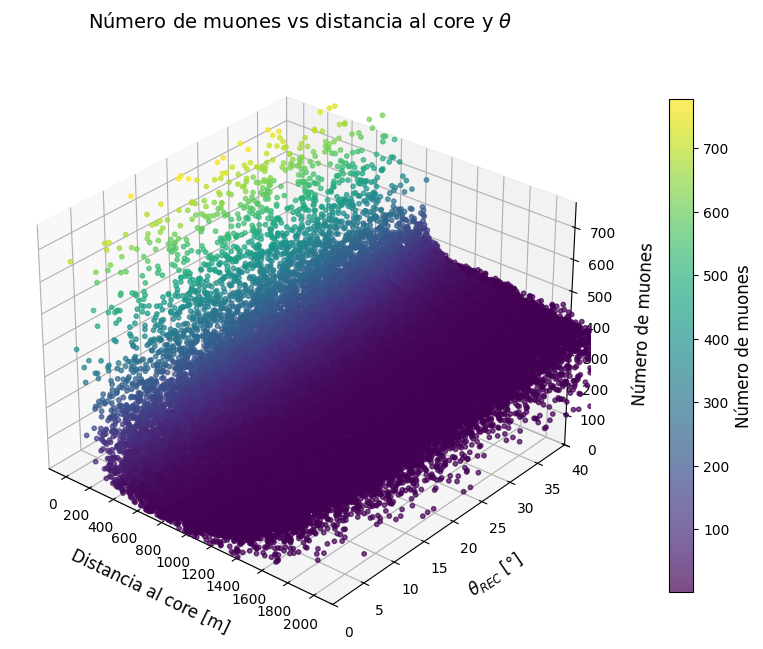

In [30]:
print("Generando gráfico 3D...")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# (Opcional) Filtremos un poco para que el plot sea más claro
# ej: sacamos counters sin muones o muy lejanos
df_plot = df_new[
    (df_new['nMuones'] > 0) &
    (df_new['r_core'] < 2000) # (Ajustá este límite si es necesario)
]

# Scatter
sc = ax.scatter(
    df_plot["r_core"],
    df_plot["theta_REC"],  # <-- Columna renombrada
    df_plot["nMuones"],
    c=df_plot["nMuones"], 
    cmap="viridis", 
    alpha=0.7,
    s=10 # Hago los puntos un poco más chicos
)

# Labels
ax.set_xlabel("Distancia al core [m]", fontsize=12, labelpad=10)
ax.set_ylabel(r"$\theta_{REC}$ [°]", fontsize=12, labelpad=10) # <-- Label actualizado
ax.set_zlabel("Número de muones", fontsize=12, labelpad=10)
plt.title(r"Número de muones vs distancia al core y $\theta$", fontsize=14, pad=20)

# Mejorar ticks (usando tu configuración)
ax.set_xticks(np.arange(0, 2000 + 1, 200))
ax.set_yticks(np.arange(0, 40 + 1, 5))
ax.set_ylim(0, 40) # (Tal vez quieras subir este límite si tus datos llegan a 60°)

# Zticks: Usar un log-scale o binear puede ser mejor
# pero siguiendo tu código original:
z_max = df_plot["nMuones"].max()
ax.set_zticks(np.arange(0, z_max + 1, 100)) # Ajustado a 100, ya que 50 era muy denso
ax.set_zlim(0, z_max) # Asegurarse de que el eje Z llegue al máximo

# Añadir barra de color
cbar = plt.colorbar(sc, pad=0.1, shrink=0.8)
cbar.set_label("Número de muones", fontsize=12)

# Rotar la vista
ax.view_init(elev=30, azim=310)

# Grid
ax.grid(True)

plt.show()

In [31]:
# --- 3. Crear DataFrame de EVENTOS ---
# Columnas que son únicas para cada evento (lluvia)
event_cols = [
    "run_number",
    "event_id",
    "logE_MC", "theta_MC", "phi_MC", 
    "primary", # 'primary' es de MC, así que también es por evento
    "logE_REC", "theta_REC", "phi_REC"
]

# Usamos drop_duplicates() para colapsar las 10-12 filas de cada evento en UNA sola.
df_events = df_new[event_cols].drop_duplicates()

print(f"DataFrame 'df_events' (lluvias) creado con {len(df_events)} filas únicas.")
df_events.head()

DataFrame 'df_events' (lluvias) creado con 23332 filas únicas.


,run_number,event_id,logE_MC,theta_MC,phi_MC,primary,logE_REC,theta_REC,phi_REC
0,10,Library_Prague_Santos_Yushkov:Run_10000:Shower...,17.557002,10.497525,266.129022,He,17.424415,9.516247,269.459517
7,10,Library_Prague_Santos_Yushkov:Run_10001:Shower...,17.514259,3.048157,315.899666,He,17.423894,3.140957,323.483553
15,10,Library_Prague_Santos_Yushkov:Run_10002:Shower...,17.509618,28.251578,331.123960,He,17.406819,27.135014,331.405738
24,10,Library_Prague_Santos_Yushkov:Run_10003:Shower...,17.896363,36.831416,117.406958,He,17.780786,36.541166,118.938084
37,10,Library_Prague_Santos_Yushkov:Run_10004:Shower...,17.755350,53.969303,169.547926,He,17.587915,53.550577,168.552741


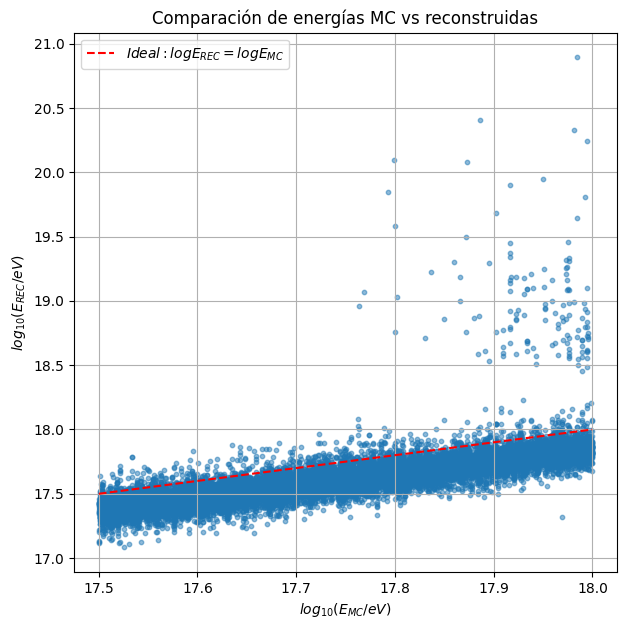

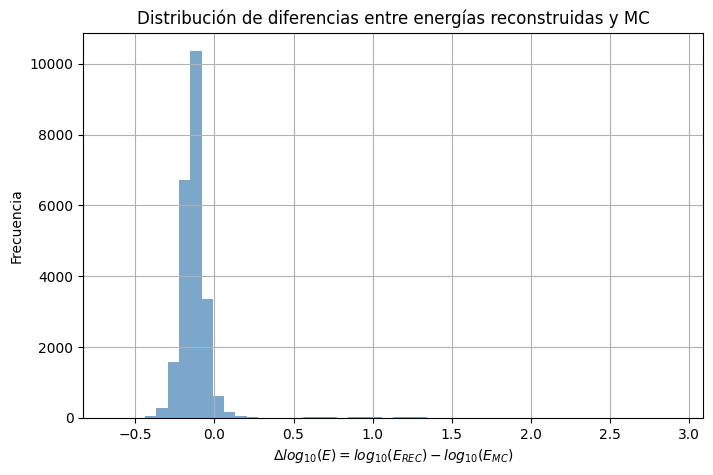

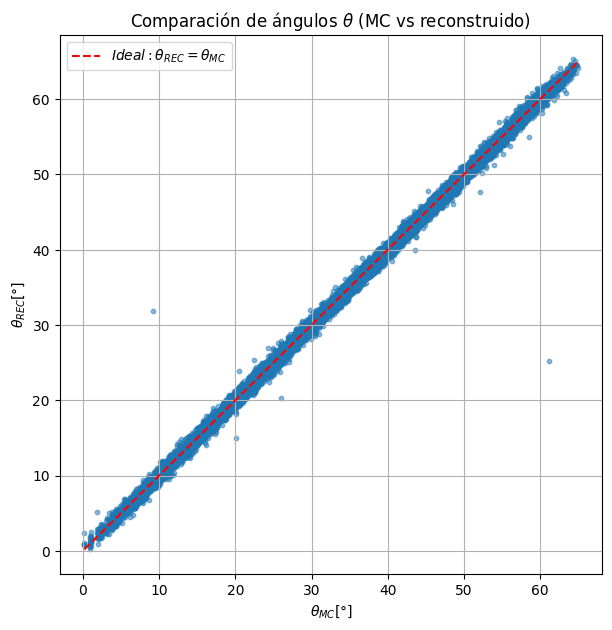

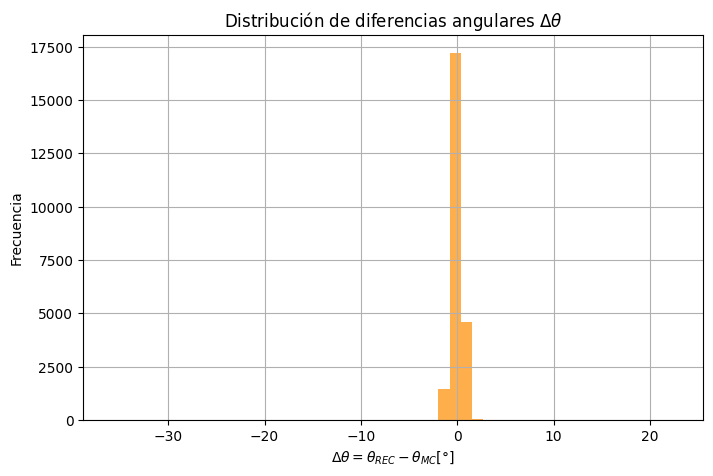

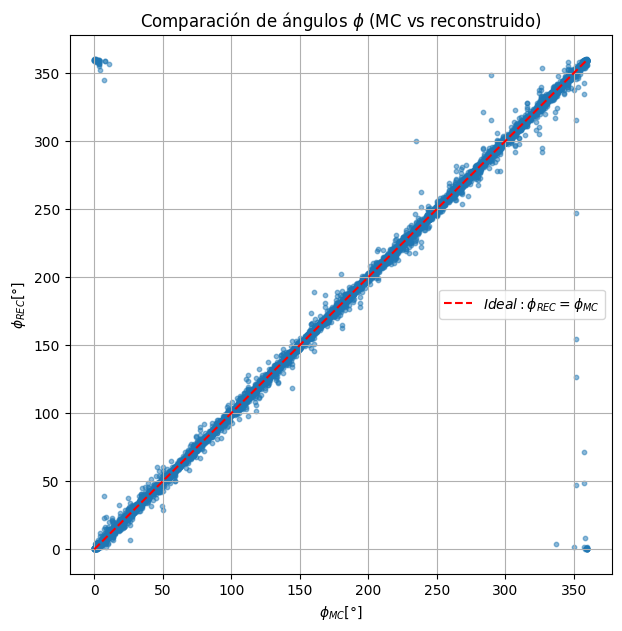

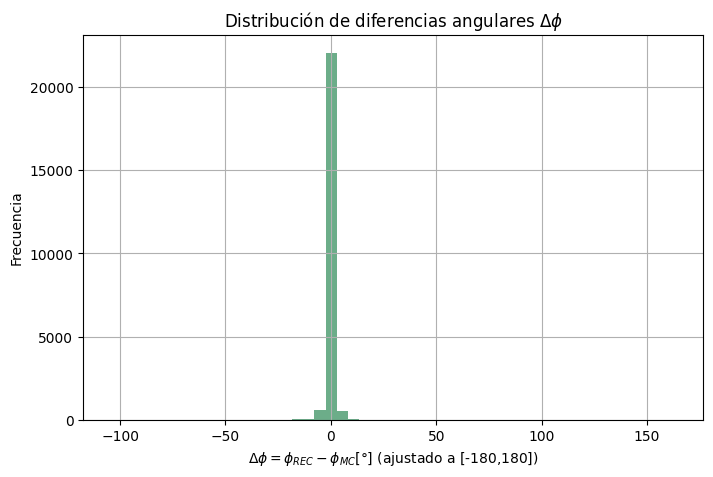

=== Energía (log10) ===
Promedio ΔlogE: -0.1270
Desviación estándar ΔlogE: 0.1179

=== Ángulo cenital θ ===
Promedio Δθ: -0.0413°
Desviación estándar Δθ: 0.5828°

=== Ángulo azimutal φ ===
Mediana Δφ: 0.0105°
MAD Δφ: 0.5599°


In [32]:
# --- 1. PLOTS DE RESOLUCIÓN (usando df_events) ---

# -------------------------------
# Comparar logE_MC vs logE_REC
# -------------------------------
plt.figure(figsize=(7, 7))
# ❗️ CAMBIO: df_all -> df_events
plt.scatter(df_events["logE_MC"], df_events["logE_REC"], s=10, alpha=0.5)
plt.plot([df_events["logE_MC"].min(), df_events["logE_MC"].max()],
         [df_events["logE_MC"].min(), df_events["logE_MC"].max()],
         'r--', label=r"$Ideal: logE_{REC} = logE_{MC}$")

plt.xlabel(r"$log_{10}(E_{MC} / eV)$")
plt.ylabel(r"$log_{10}(E_{REC} / eV)$")
plt.title("Comparación de energías MC vs reconstruidas")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Diferencia ΔlogE = logE_REC - logE_MC
# -------------------------------
# ❗️ CAMBIO: df_all -> df_events
deltaE = df_events["logE_REC"] - df_events["logE_MC"]
# (El resto de tu código de histograma es idéntico)
plt.figure(figsize=(8, 5))
plt.hist(deltaE.dropna(), bins=50, alpha=0.7, color='steelblue') # .dropna() por seguridad
plt.xlabel(r"$\Delta log_{10}(E) = log_{10}(E_{REC}) - log_{10}(E_{MC})$")
plt.ylabel("Frecuencia")
plt.title("Distribución de diferencias entre energías reconstruidas y MC")
plt.grid(True)
plt.show()

# -------------------------------
# THETA
# -------------------------------
# ❗️ CAMBIO: df_all -> df_events
plt.figure(figsize=(7,7))
plt.scatter(df_events["theta_MC"], df_events["theta_REC"], s=10, alpha=0.5)
plt.plot([df_events["theta_MC"].min(), df_events["theta_MC"].max()],
         [df_events["theta_MC"].min(), df_events["theta_MC"].max()],
         'r--', label=r"$Ideal: \theta_{REC} = \theta_{MC}$")
plt.xlabel(r"$\theta_{MC} [°]$")
plt.ylabel(r"$\theta_{REC} [°]$")
plt.title(r"Comparación de ángulos $\theta$ (MC vs reconstruido)")
plt.legend()
plt.grid(True)
plt.show()

# ❗️ CAMBIO: df_all -> df_events
delta_theta = df_events["theta_REC"] - df_events["theta_MC"]

plt.figure(figsize=(8,5))
plt.hist(delta_theta.dropna(), bins=50, alpha=0.7, color='darkorange') # .dropna()
plt.xlabel(r"$\Delta \theta = \theta_{REC} - \theta_{MC} [°]$")
plt.ylabel("Frecuencia")
plt.title(r"Distribución de diferencias angulares $\Delta \theta$")
plt.grid(True)
plt.show()

# -------------------------------
# PHI
# -------------------------------
# ❗️ CAMBIO: df_all -> df_events
plt.figure(figsize=(7,7))
plt.scatter(df_events["phi_MC"], df_events["phi_REC"], s=10, alpha=0.5)
plt.plot([df_events["phi_MC"].min(), df_events["phi_MC"].max()],
         [df_events["phi_MC"].min(), df_events["phi_MC"].max()],
         'r--', label=r"$Ideal: \phi_{REC} = \phi_{MC}$")
plt.xlabel(r"$\phi_{MC} [°]$")
plt.ylabel(r"$\phi_{REC} [°]$")
plt.title(r"Comparación de ángulos $\phi$ (MC vs reconstruido)")
plt.legend()
plt.grid(True)
plt.show()

# Cuidar el wrap-around de phi (0–360)
# ❗️ CAMBIO: df_all -> df_events
delta_phi = (df_events["phi_REC"] - df_events["phi_MC"] + 180) % 360 - 180

plt.figure(figsize=(8,5))
plt.hist(delta_phi.dropna(), bins=50, alpha=0.7, color='seagreen') # .dropna()
plt.xlabel(r"$\Delta \phi = \phi_{REC} - \phi_{MC} [°]$ (ajustado a [-180,180])")
plt.ylabel("Frecuencia")
plt.title(r"Distribución de diferencias angulares $\Delta \phi$")
plt.grid(True)
plt.show()

# -------------------------------
# Resumen de Métricas
# -------------------------------
# Mediana y MAD de Δφ
median_phi = np.median(delta_phi.dropna())
mad_phi = np.median(np.abs(delta_phi.dropna() - median_phi))

print("=== Energía (log10) ===")
print(f"Promedio ΔlogE: {deltaE.mean():.4f}")
print(f"Desviación estándar ΔlogE: {deltaE.std():.4f}\n")

print("=== Ángulo cenital θ ===")
print(f"Promedio Δθ: {delta_theta.mean():.4f}°")
print(f"Desviación estándar Δθ: {delta_theta.std():.4f}°\n")

print("=== Ángulo azimutal φ ===")
print(f"Mediana Δφ: {median_phi:.4f}°")
print(f"MAD Δφ: {mad_phi:.4f}°")

Estadísticos por counter:
   counterId   promedio    std_dev  cantidad
0     104001  12.756425  39.962789      5869
1     104002  13.552885  40.254524      5832
2     104003  12.670893  37.628248      5888
3     104004  14.183523  43.566954      5870
4     104005  12.551969  36.431726      5921


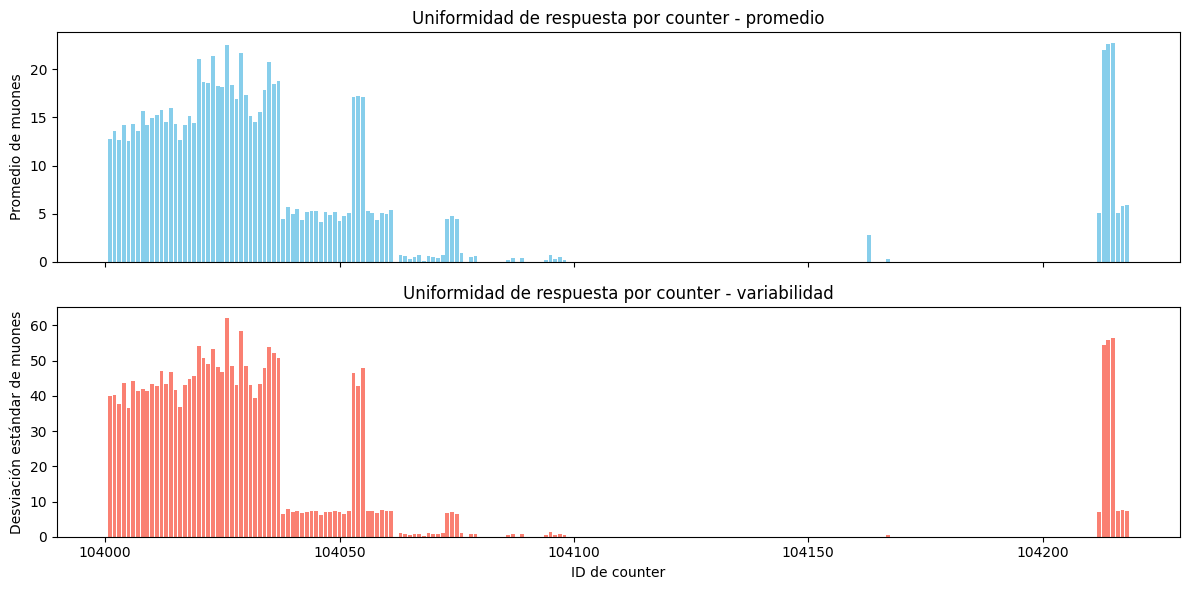

In [33]:
# -------------------------------
# MÉTODO NUEVO (PANDAS, 1 LÍNEA)
# -------------------------------
# Agrupa por 'counterId', toma la columna 'nMuones' y calcula 
# el promedio, la desviación estándar y el conteo para cada counter.
counter_stats = df_new.groupby('counterId')['nMuones'].agg(
    promedio='mean', 
    std_dev='std',
    cantidad='count'
).reset_index()

print("Estadísticos por counter:")
print(counter_stats.head())

# -------------------------------
# Visualización (adaptada al nuevo DataFrame)
# -------------------------------
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Promedio
axs[0].bar(counter_stats['counterId'], counter_stats['promedio'], color='skyblue')
axs[0].set_ylabel("Promedio de muones")
axs[0].set_title("Uniformidad de respuesta por counter - promedio")

# Desviación estándar
axs[1].bar(counter_stats['counterId'], counter_stats['std_dev'], color='salmon')
axs[1].set_ylabel("Desviación estándar de muones")
axs[1].set_xlabel("ID de counter")
axs[1].set_title("Uniformidad de respuesta por counter - variabilidad")

plt.tight_layout()
plt.show()

Rango de Theta en los datos: [0.22°, 65.29°]
Bordes de bins en Theta (grados): [ 0.         21.76911976 31.63362425 39.96810814 47.87939805 56.02532269
 65.29007814]
Ploteando bin 0: Mapa polar, $\theta \approx$ [0.0°, 21.8°]


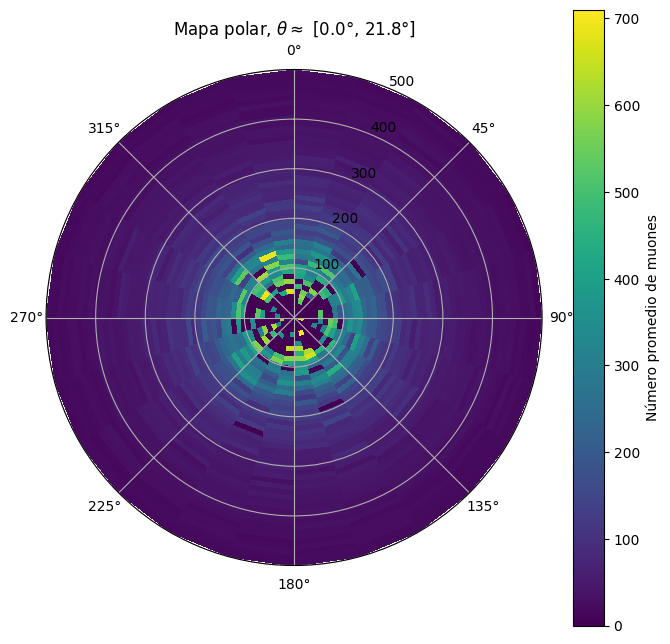

Ploteando bin 1: Mapa polar, $\theta \approx$ [21.8°, 31.6°]


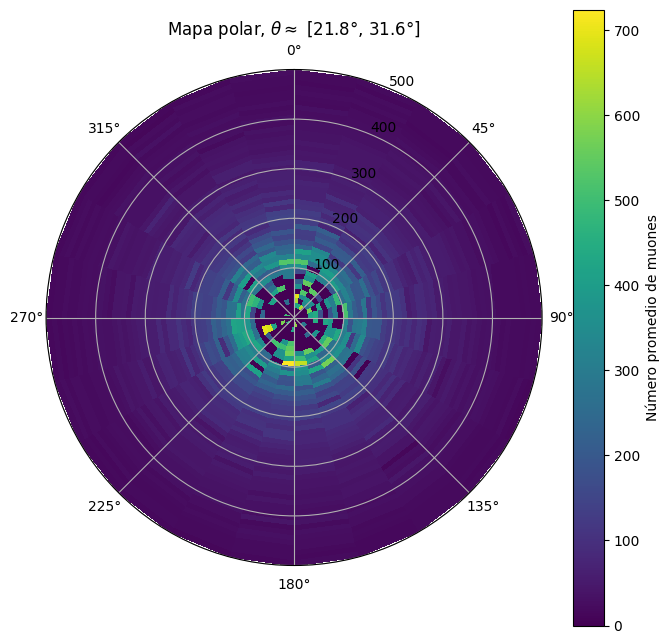

Ploteando bin 2: Mapa polar, $\theta \approx$ [31.6°, 40.0°]


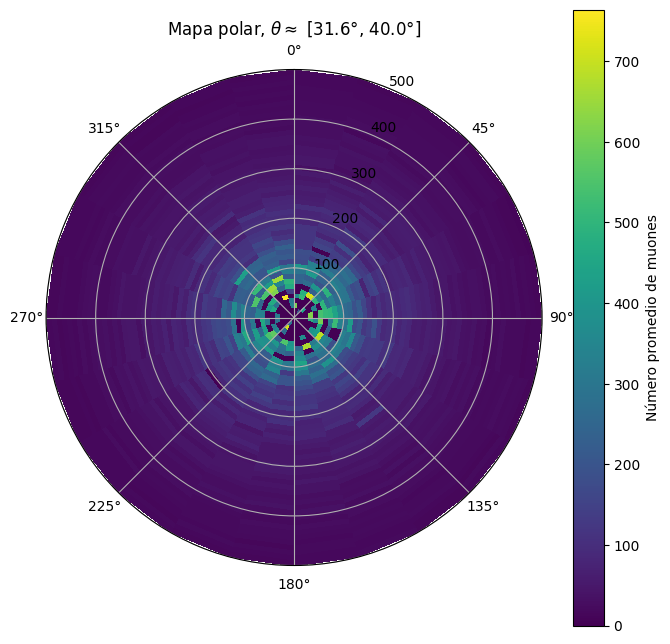

Ploteando bin 3: Mapa polar, $\theta \approx$ [40.0°, 47.9°]


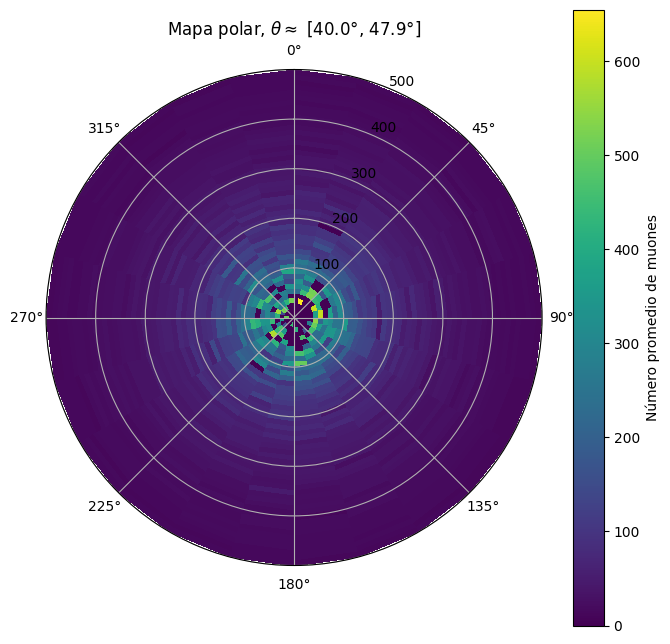

Ploteando bin 4: Mapa polar, $\theta \approx$ [47.9°, 56.0°]


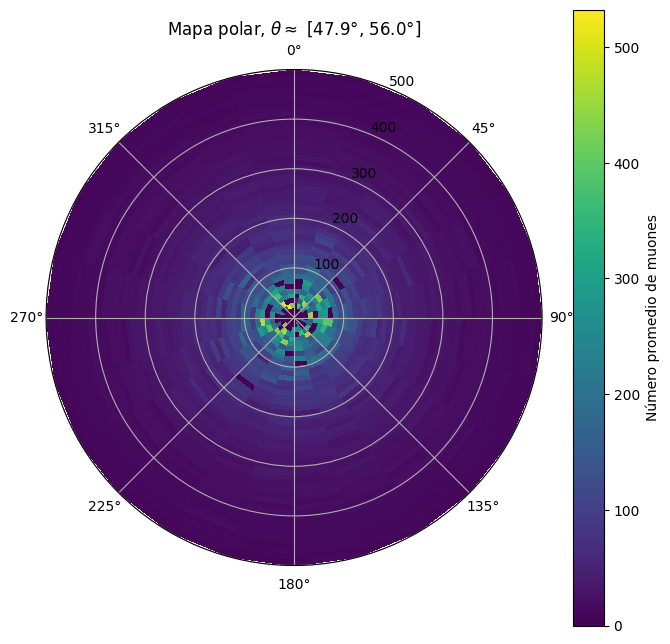

Ploteando bin 5: Mapa polar, $\theta \approx$ [56.0°, 65.3°]


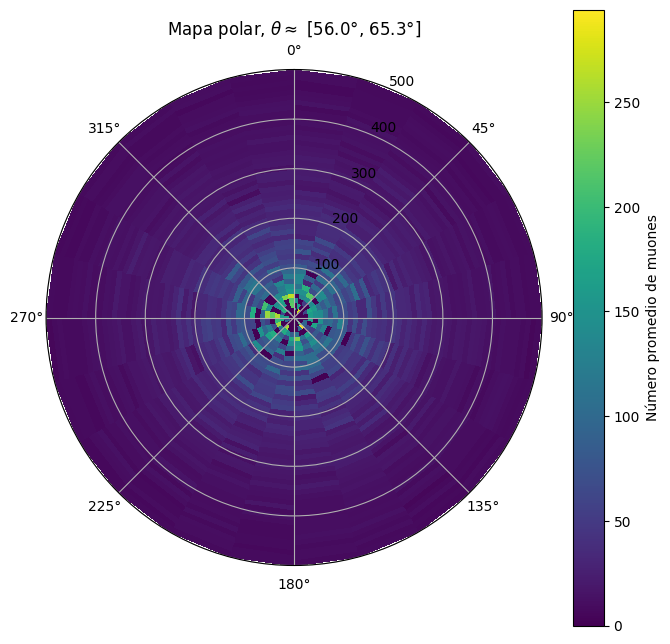

In [36]:
# --- 3. MAPA POLAR (usando df_new) ---

# -------------------------------
# Parámetros de binning (r y phi)
# -------------------------------
r_max = 500
r_bin_size = 10
phi_bins = 24 # 100 es demasiado para ver asimetrías, 12 o 24 es mejor

r_bins = np.arange(0, r_max + r_bin_size, r_bin_size)
phi_edges = np.linspace(0, 2*np.pi, phi_bins + 1)
R, Phi = np.meshgrid(r_bins, phi_edges) # Meshgrid para el plot

# -------------------------------
# Binning en sin^2(theta)
# -------------------------------
N_theta_bins = 6
theta_min_deg = 0
theta_max_deg = 66

# Verificamos el rango real
theta_min_real = df_new['theta_REC'].min()
theta_max_real = df_new['theta_REC'].max()
print(f"Rango de Theta en los datos: [{theta_min_real:.2f}°, {theta_max_real:.2f}°]")
# Usamos el máximo real si es menor a 65
theta_max_deg = min(theta_max_deg, theta_max_real) 

# 1. Crear los bins en el espacio de sin^2(theta)
s2_min = np.sin(np.deg2rad(theta_min_deg))**2
s2_max = np.sin(np.deg2rad(theta_max_deg))**2
s2_bins = np.linspace(s2_min, s2_max, N_theta_bins + 1)

# 2. Convertir los bordes de los bins de vuelta a grados (para las etiquetas)
theta_bins_deg = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))

print(f"Bordes de bins en Theta (grados): {theta_bins_deg}")

# 3. Asignar cada FILA (counter) a un bin de theta
# Convertimos theta_REC a sin^2(theta) para binear
df_new['s2_theta'] = np.sin(np.deg2rad(df_new['theta_REC']))**2
# pd.cut asigna cada fila a un bin
# (labels=False nos da un índice: 0, 1, 2, 3, 4, 5)
df_new['theta_bin'] = pd.cut(df_new['s2_theta'], bins=s2_bins, labels=False, include_lowest=True)

# -------------------------------
# Iterar sobre cada bin de theta
# -------------------------------
# Filtramos datos malos de una vez
df_mapa_total = df_new[
    (df_new['r_core'].between(0, r_max)) &
    (df_new['nMuones'].notna()) &
    (df_new['phi_plane'].notna())
].copy()


for i in range(N_theta_bins):
    
    # Seleccionar solo las filas de este bin de theta
    df_bin = df_mapa_total[df_mapa_total['theta_bin'] == i]
    
    if df_bin.empty:
        print(f"Sin datos para el bin de theta {i}. Saltando.")
        continue

    # Título para el plot
    th_min_label = theta_bins_deg[i]
    th_max_label = theta_bins_deg[i+1]
    plot_title = f"Mapa polar, $\\theta \\approx$ [{th_min_label:.1f}°, {th_max_label:.1f}°]"
    print(f"Ploteando bin {i}: {plot_title}")

    # -------------------------------
    # Llenado de la grilla (¡VECTORIZADO!)
    # -------------------------------
    
    # Z = Suma de nMuones en cada bin (r, phi)
    Z, _, _ = np.histogram2d(
        x=df_bin['r_core'],
        y=df_bin['phi_plane'],
        bins=[r_bins, phi_edges],
        weights=df_bin['nMuones']
    )

    # counts = Número de entradas en cada bin (r, phi)
    counts, _, _ = np.histogram2d(
        x=df_bin['r_core'],
        y=df_bin['phi_plane'],
        bins=[r_bins, phi_edges]
    )

    # Transponemos porque pcolormesh espera (phi, r)
    Z_T = Z.T
    counts_T = counts.T

    # Promedio de muones por bin
    Z_avg = np.divide(Z_T, counts_T, out=np.zeros_like(Z_T), where=counts_T != 0)

    # -------------------------------
    # Plot polar
    # -------------------------------
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    c = ax.pcolormesh(Phi, R, Z_avg, cmap='viridis', shading='auto')
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlim(0, r_max)
    fig.colorbar(c, ax=ax, label="Número promedio de muones")
    plt.title(plot_title)
    plt.show()